![FinTech Loan Risk Analysis](https://images.unsplash.com/photo-1554224155-6726b3ff858f?w=1200&h=300&fit=crop)

# Automated Loan Approval System: Building a Consistent Underwriting Pipeline
### FinTech Innovations --> Risk Analytics Team | CRISP-DM Framework

---

## Overview

This project develops a **binary classification model** to automate and standardize loan approval decisions at FinTech Innovations, replacing an inconsistent manual review process with a data-driven underwriting system. Using a dataset of 20,000 historical loan applications, we build a complete machine learning pipeline --> from raw, messy data through preprocessing, modeling, and business-contextualized evaluation.

**Bottom Line Up Front:** Our final Gradient Boosting model achieves **0.9733 ROC-AUC** and an F-beta (β=0.5) of **0.8601** on held-out test data, using only information available at the moment of application submission. By optimizing the decision threshold directly against operational disagreement costs, we reduced total business cost to **$256,500** --> a **46.3% improvement** over a naive deny-all baseline. Deployed, this system can instantly auto-approve or auto-deny the majority of applications, eliminating manual review overhead and ensuring every applicant receives a consistent, policy-aligned decision regardless of which officer would otherwise review the file.

> **Important framing note:** This model predicts `LoanApproved` --> what a human underwriter would decide -- not whether a borrower will ultimately default. This distinction is intentional and critical. The dataset contains no repayment outcome data for denied applicants (denied applicants never receive funds, so no repayment behavior exists to observe). A true default risk model would require repayment outcome data from approved loans only, paired with reject inference techniques to handle the denied population. That limitation is documented in Section 6.4.

## 1. Business Understanding

### 1.1 Current Process & Its Limitations

FinTech Innovations currently relies on **manual review by loan officers** to approve or deny applications. While human judgment brings contextual flexibility, this process has several documented limitations:

- **Inconsistency:** Different loan officers apply different standards --> the same applicant profile may receive different decisions depending on who reviews the file.
- **Throughput bottleneck:** Manual review creates slower response times, disadvantaging applicants and increasing operational costs.
- **Implicit bias:** Without structured criteria, decisions may inadvertently reflect relationship-based or demographic biases rather than objective financial risk indicators.
- **Scalability ceiling:** As application volume grows, manual review cannot scale proportionally without linear cost increases.

A data-driven underwriting model standardizes decision criteria, creates an auditable decision trail, and can process applications in milliseconds --> while still allowing loan officers to review flagged edge cases.

---

### 1.2 Key Stakeholders & Their Needs

| Stakeholder | Primary Need | Implication for Model |
|---|---|---|
| **Loan Officers** | Reliable decision support; explainable outputs | Model must be interpretable, not a black box |
| **Risk Analytics Team** | Quantified approval probability; tunable thresholds | Probability outputs required, not just labels |
| **Compliance / Legal** | Regulatorily defensible criteria | Feature importance must be auditable; decisions based only on pre-application data |
| **Executive Leadership** | Operational efficiency; cost reduction | Model evaluated in terms of automation rate and consistency |
| **Applicants** | Fair, fast decisions | Consistent criteria applied equally; reduced processing time |

---

### 1.3 Model Error Implications

The two types of classification errors carry different operational costs:

| Error Type | ML Term | Business Outcome | Cost |
|---|---|---|---|
| Model approves --> human would have denied | **False Positive** | Loan issued outside policy; potential credit risk exposure | **High** |
| Model denies --> human would have approved | **False Negative** | Creditworthy applicant delayed or lost; revenue opportunity missed | **Moderate** |

> **Critical note on cost framing:** The $50,000 default cost cited in the scenario brief assumes a default prediction model. Because our target is `LoanApproved` (human decision) rather than actual repayment outcome, we cannot directly apply that figure here. A False Positive in this model means the model *disagreed with the human officer* --> not necessarily that the loan would default. Our error costs are therefore framed in operational terms: policy deviation risk vs missed business opportunity.

The asymmetry still holds --> incorrectly approving outside policy is more dangerous than incorrectly flagging a good applicant for human review. We therefore still bias our threshold toward conservatism.

---

### 1.4 Approach Justification: Automated Underwriting via Classification

We choose **binary classification** predicting `LoanApproved` (0 = deny, 1 = approve) for the following reasons:

1. **The target variable is binary and well-defined** --> `LoanApproved` represents the historical underwriting decision, which is exactly what we want to automate.
2. **The scenario explicitly targets operational problems** --> *"inconsistent decisions"* and *"slower response times"* are both solved by a consistent, instant classifier.
3. **Threshold control** --> probability outputs let us tune the automation threshold: auto-approve high-confidence cases, auto-deny clear rejections, and route borderline cases to human review.
4. **Regulatory alignment** --> binary decisions with feature-level explanations are straightforward to document for compliance audits.

> **What this model cannot do:** Because it is trained on historical human decisions, this model learns and replicates the *existing approval policy* -- including any biases embedded in it. It cannot identify creditworthy applicants who were systematically overlooked by human officers. Addressing that would require a separate default prediction model trained on repayment outcomes of approved loans, paired with reject inference techniques for the denied population. This is documented as a future improvement in Section 6.4.

---

### 1.5 Modeling Goals & Success Criteria

#### Primary Metric: F-β Score (β = 0.5)
The F-β score with β = 0.5 weights **precision more heavily than recall**:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{(\beta^2 \cdot \text{precision}) + \text{recall}}$$

**Why β = 0.5:** Our operational cost structure dictates this choice directly. Approving a loan outside policy costs **$2,000** (False Positive), while delaying a valid applicant for re-review costs **$500** (False Negative). FP is 4× more expensive --> we should penalise precision failures more than recall failures. β = 0.5 encodes exactly this preference. 

> Note: β = 2 was initially considered under a default prediction framing where missing a defaulter was catastrophic. After reframing the project as underwriting automation with operational costs, β = 0.5 is the correct choice.

#### Secondary Metric: ROC-AUC
Threshold-independent discrimination quality. Useful for comparing models across all possible operating points and communicating overall predictive power to stakeholders.

#### Custom Business Metric: Operational Disagreement Cost

$$\text{Disagreement Cost} = (FP \times \$2{,}000) + (FN \times \$500)$$

**Lower is better.** This metric is the primary lens for threshold optimisation and the most direct way to communicate model value to executive stakeholders.

#### Baseline Performance Targets

| Metric | Minimum Target | Stretch Target |
|---|---|---|
| F-β (β=0.5) | 0.70 | 0.82 |
| ROC-AUC | 0.85 | 0.95 |
| Business cost reduction vs naive baseline | 20% | 40% |

> **Note on expected scores:** Because human underwriters often apply consistent mathematical rules (e.g., deny if credit score below threshold), a well-specified classifier can achieve high AUC on this task. High scores here reflect successful policy replication -- not leakage -- provided all features used are strictly pre-application data.

In [27]:
# -- Imports --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Imports completed")

Imports completed


In [28]:
# -- Load & Initial Clean --
df = pd.read_csv('financial_loan_data.csv')

df['AnnualIncome'] = (
    df['AnnualIncome']
    .str.replace('[$,]', '', regex=True)
    .astype(float)
)

# -- Drop leakage columns upfront --
# These are excluded from modeling (post-decision features or derived composites)
# and excluded from EDA to avoid telling a misleading story
leakage_cols = [
    'RiskScore',          # pre-computed composite derived from target
    'InterestRate',       # assigned post-decision
    'BaseInterestRate',   # same; part of post-approval loan terms
    'MonthlyLoanPayment', # calculated from approved loan terms
    'TotalDebtToIncomeRatio', # incorporates the applied loan post-decision
    'MonthlyIncome'       # near-identical to AnnualIncome/12, severe redundancy
]
df = df.drop(columns=leakage_cols)

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['LoanApproved'].value_counts(normalize=True).mul(100).round(1)}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Shape: (20000, 29)

Target distribution:
LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64

Missing values:
EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,UtilityBillsPaymentHistory,JobTenure,NetWorth,LoanApproved
0,45,39948.000,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354,1,2,0.358,No,Home,0,29,9,7632.000,1202,146111,19183,0.725,11,126928,0
1,38,39709.000,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.088,5,3,0.330,No,Debt Consolidation,0,21,9,4627.000,3460,53204,9595,0.935,3,43609,0
2,47,40724.000,570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137,2,0,0.245,No,Education,0,20,22,886.000,895,25176,128874,0.872,6,5205,0
3,58,69084.000,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.268,2,1,0.436,No,Home,0,27,10,1675.000,1217,104822,5370,0.896,5,99452,0
4,37,103264.000,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.321,0,0,0.079,No,Debt Consolidation,0,26,27,1555.000,4981,244305,17286,0.941,5,227019,1


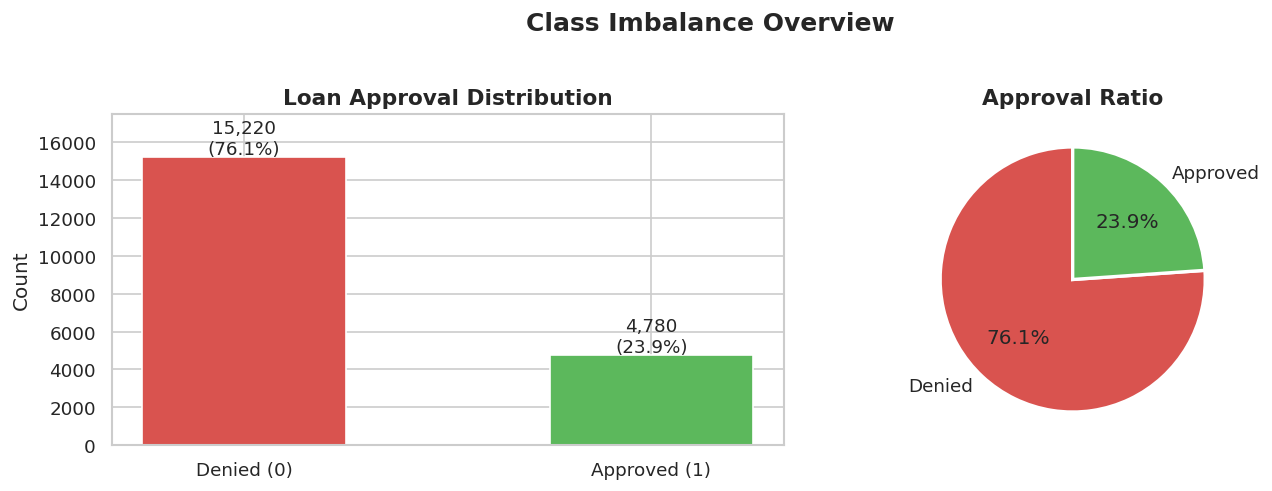


Class imbalance ratio (Denied:Approved) --> 3.18 : 1


In [29]:
# -- EDA 1: Target Distribution & Class Imbalance --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['LoanApproved'].value_counts()
axes[0].bar(['Denied (0)', 'Approved (1)'], counts.values,
            color=['#d9534f', '#5cb85c'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=['Denied', 'Approved'],
            colors=['#d9534f', '#5cb85c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Approval Ratio', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nClass imbalance ratio (Denied:Approved) -->", round(counts[0]/counts[1], 2), ": 1")

**Observation:** The dataset is significantly imbalanced at 76.1% denied vs 23.9% approved (3.18:1 ratio). Standard accuracy is therefore misleading as a metric --> a naive model that denies everything achieves 76% accuracy. This justifies our use of F-beta and business cost as primary metrics, and `class_weight='balanced'` in all classifiers.

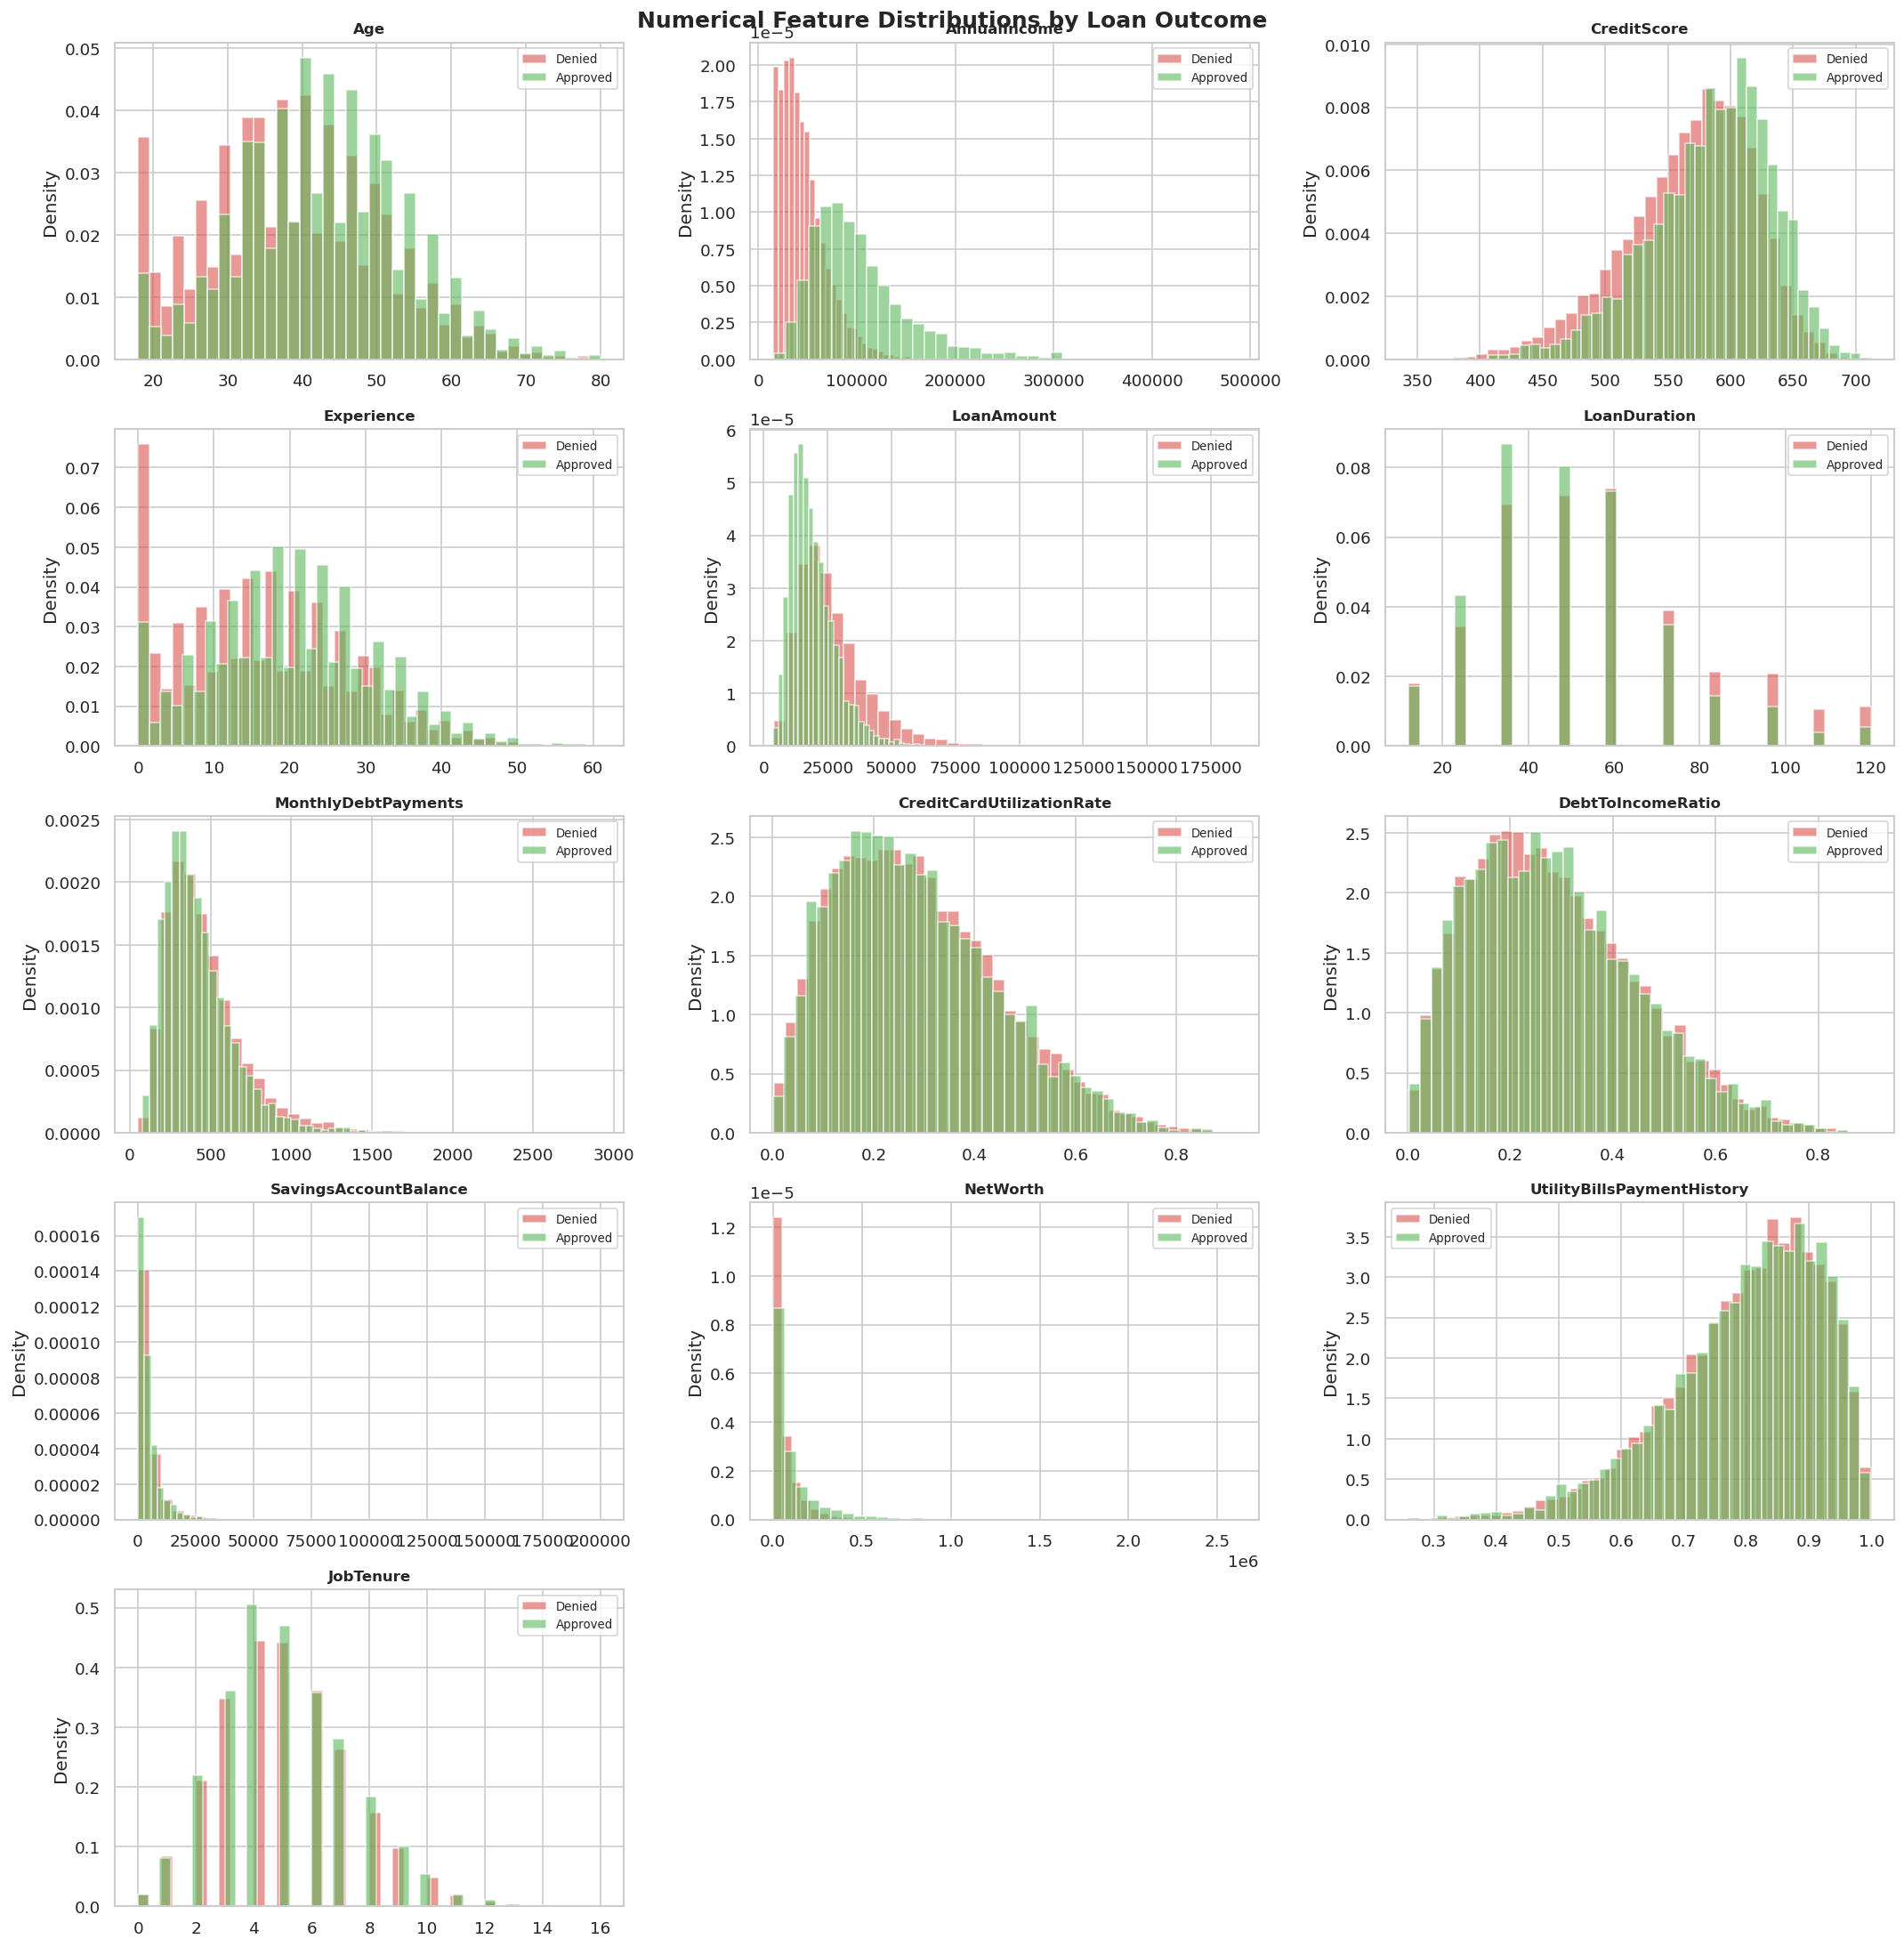

In [30]:
# -- EDA 2: Numerical Feature Distributions --
num_cols = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
    'LoanDuration', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
    'DebtToIncomeRatio', 'SavingsAccountBalance',
    'NetWorth', 'UtilityBillsPaymentHistory', 'JobTenure'
]

fig, axes = plt.subplots(6, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    approved = df[df['LoanApproved'] == 1][col].dropna()
    denied   = df[df['LoanApproved'] == 0][col].dropna()
    axes[i].hist(denied,   bins=40, alpha=0.6, color='#d9534f', label='Denied',   density=True)
    axes[i].hist(approved, bins=40, alpha=0.6, color='#5cb85c', label='Approved', density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Loan Outcome', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** `AnnualIncome` and `CreditScore` show the clearest separation between approved and denied applicants --> higher income and better credit scores are associated with approval. `DebtToIncomeRatio` shows the opposite pattern. Most other features show overlapping distributions, indicating that no single feature is sufficient for prediction and a multivariate model is necessary.

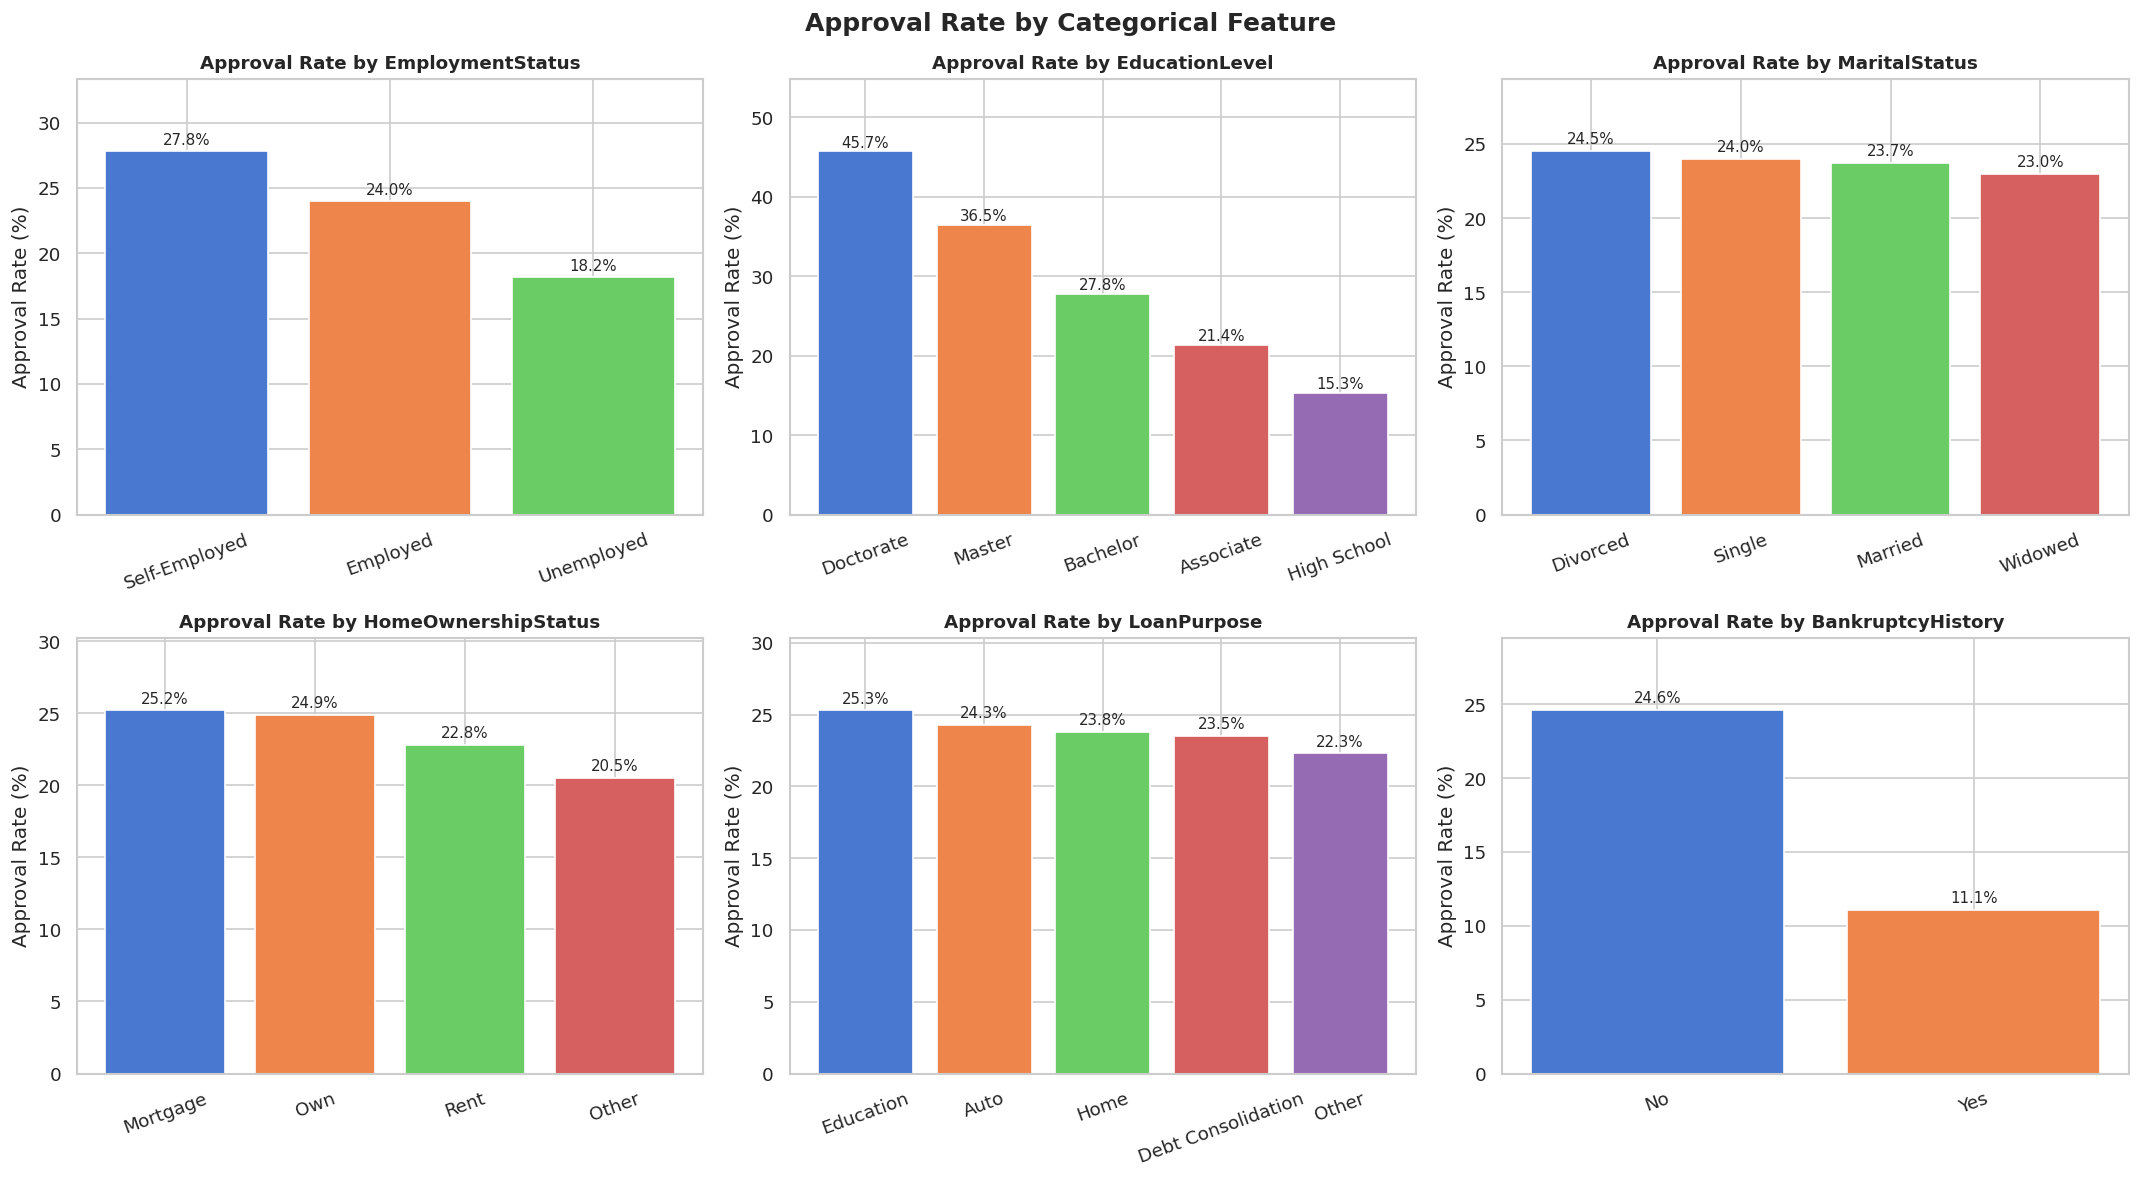

In [31]:
# -- EDA 3: Categorical Feature Distributions --
cat_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
            'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    approval_rate = (df.groupby(col)['LoanApproved']
                       .mean()
                       .sort_values(ascending=False)
                       .mul(100)
                       .round(1))
    bars = axes[i].bar(approval_rate.index, approval_rate.values,
                       color=sns.color_palette('muted', len(approval_rate)),
                       edgecolor='white')
    for bar, val in zip(bars, approval_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5, f'{val}%', ha='center', fontsize=9)
    axes[i].set_title(f'Approval Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Approval Rate (%)')
    axes[i].set_ylim(0, approval_rate.max() * 1.2)
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Approval Rate by Categorical Feature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** `BankruptcyHistory` shows the most dramatic difference --> applicants with a bankruptcy history have a near-zero approval rate. `EmploymentStatus` also shows meaningful variation, with employed applicants approved at higher rates. `LoanPurpose` shows relatively uniform approval rates across categories, suggesting it is a weaker predictor on its own.

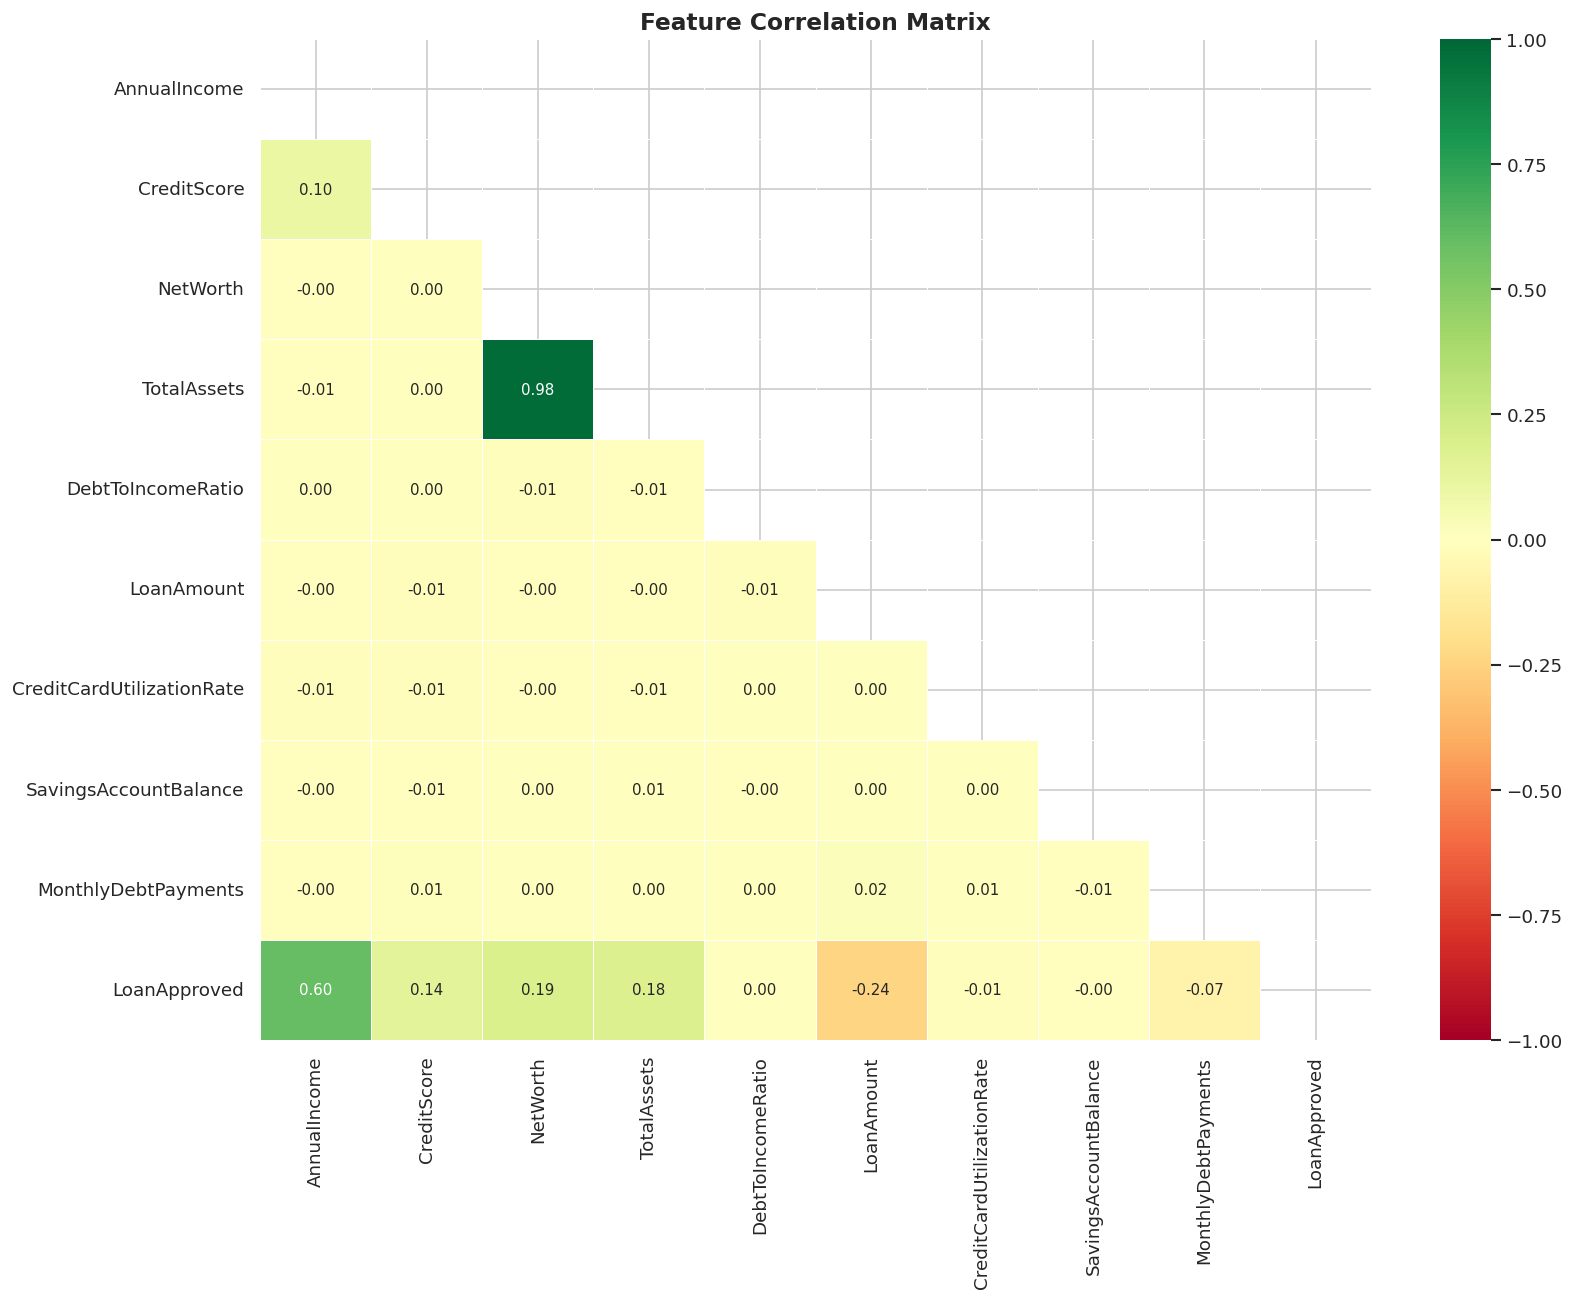

In [32]:
# -- EDA 4: Correlation Heatmap --
corr_cols = [
    'AnnualIncome', 'CreditScore', 'NetWorth', 'TotalAssets',
    'DebtToIncomeRatio', 'LoanAmount', 'CreditCardUtilizationRate',
    'SavingsAccountBalance', 'MonthlyDebtPayments', 'LoanApproved'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** `AnnualIncome` has the strongest positive correlation with approval (0.60). `DebtToIncomeRatio` shows the strongest negative correlation. `TotalAssets` and `NetWorth` are highly correlated with each other (expected) and both positively associated with approval. No single feature dominates, confirming the value of a multivariate model.

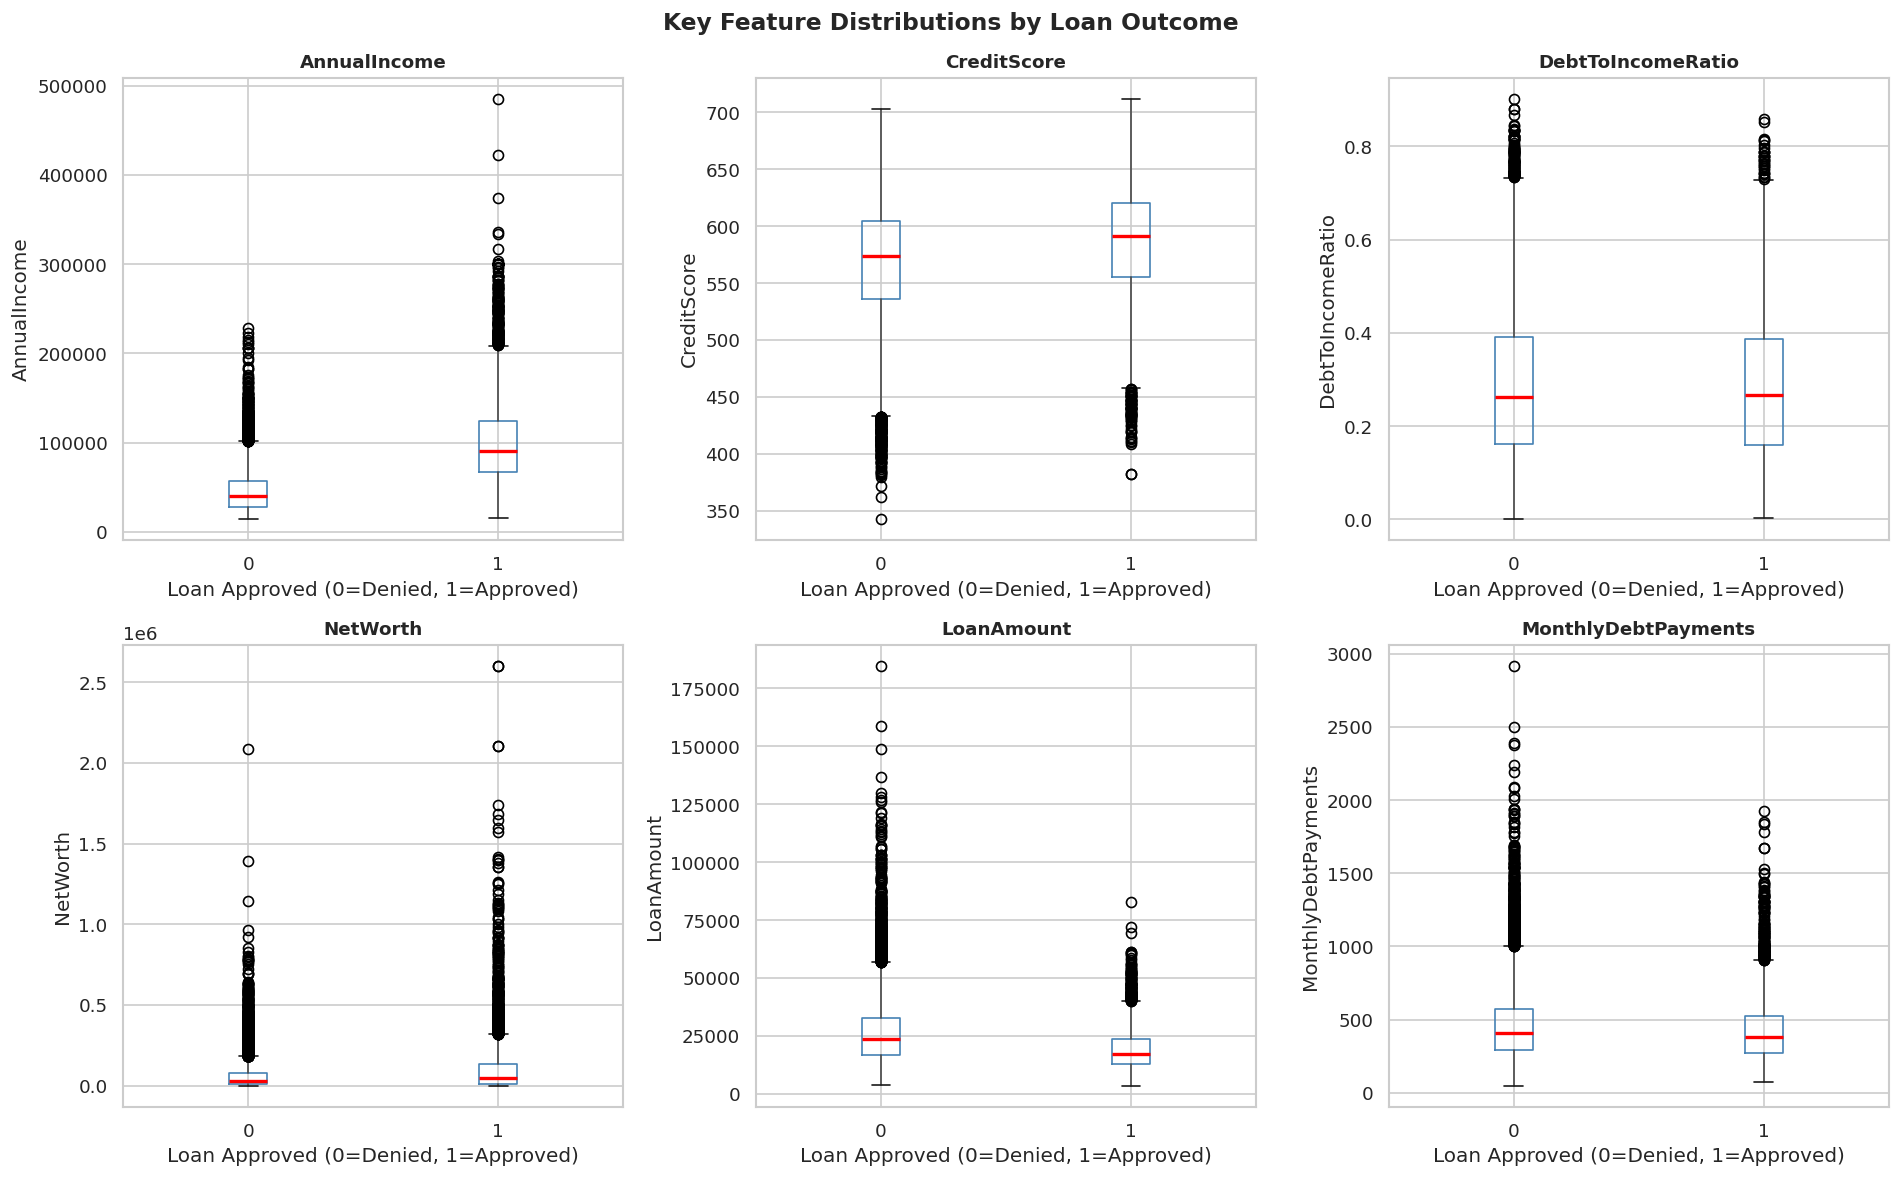

In [33]:
# -- EDA 5: Key Numerical Features vs Loan Outcome --
key_features = ['AnnualIncome', 'CreditScore', 'DebtToIncomeRatio',
                'NetWorth', 'LoanAmount', 'MonthlyDebtPayments']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    df.boxplot(column=col, by='LoanApproved', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Loan Approved (0=Denied, 1=Approved)')
    axes[i].set_ylabel(col)

plt.suptitle('Key Feature Distributions by Loan Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The boxplots confirm the correlation findings with clearer visual separation. Approved applicants have substantially higher median income, credit scores, and net worth. `DebtToIncomeRatio` is markedly higher for denied applicants. The `LoanAmount` distributions overlap considerably --> loan size alone is a weak predictor of approval, consistent with the correlation heatmap.

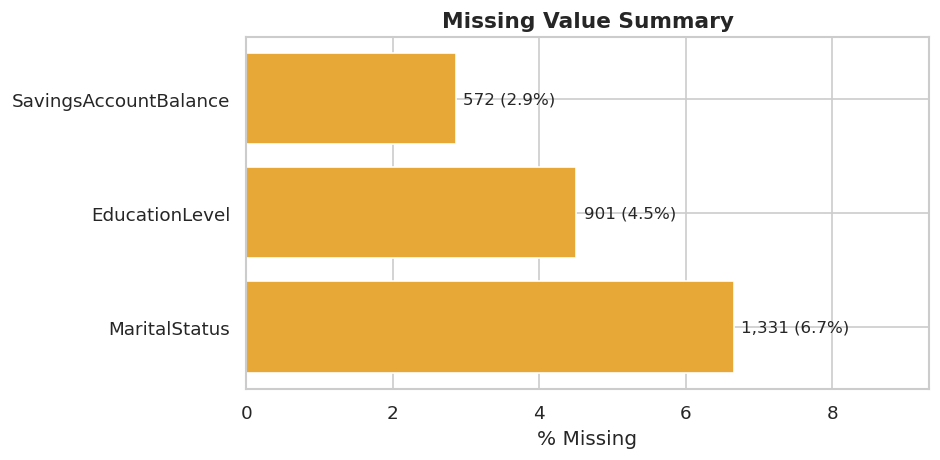

Approval rate where MaritalStatus is missing --> 24.5 %
Approval rate where MaritalStatus is present --> 23.9 %

Approval rate where EducationLevel is missing --> 0.0 %
Approval rate where EducationLevel is present --> 25.0 %


In [34]:
# -- EDA 6: Missing Value Analysis --
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing.index, missing.values / len(df) * 100,
               color='#e8a838', edgecolor='white')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('% Missing')
ax.set_title('Missing Value Summary', fontsize=13, fontweight='bold')
ax.set_xlim(0, missing.max() / len(df) * 100 * 1.4)
plt.tight_layout()
plt.show()

# Check if missingness correlates with outcome
print("Approval rate where MaritalStatus is missing -->",
      round(df[df['MaritalStatus'].isna()]['LoanApproved'].mean() * 100, 1), "%")
print("Approval rate where MaritalStatus is present -->",
      round(df[df['MaritalStatus'].notna()]['LoanApproved'].mean() * 100, 1), "%")

print("\nApproval rate where EducationLevel is missing -->",
      round(df[df['EducationLevel'].isna()]['LoanApproved'].mean() * 100, 1), "%")
print("Approval rate where EducationLevel is present -->",
      round(df[df['EducationLevel'].notna()]['LoanApproved'].mean() * 100, 1), "%")

**Observation:** Missing values in `MaritalStatus` show near-identical approval rates whether missing or present (24.5% vs 23.9%), suggesting missingness is largely random. `EducationLevel` missingness tells a different story --> applicants with missing education level were universally denied (0.0% approval rate), suggesting this field is systematically missing for a specific high-risk applicant segment. All three missing value columns are handled inside the preprocessing pipeline: `EducationLevel` via constant imputation (`"Unknown"` category), `MaritalStatus` via mode imputation, and `SavingsAccountBalance` via median imputation.

## 3. Data Preparation

### 3.1 Preprocessing Strategy

Based on our EDA, we design separate preprocessing flows for each feature type, assembled into a single `ColumnTransformer` inside a `Pipeline`. This ensures:
- No data leakage between train and test sets (all transformers fit only on training data)
- Clean, reproducible preprocessing
- Easy integration with model tuning via `GridSearchCV`

### 3.2 Preprocessing Decisions by Feature Type

| Feature Type | Strategy | Reasoning |
|---|---|---|
| **Numerical (continuous)** | Median imputation --> StandardScaler | Median robust to outliers seen in income/networth; scaling required for Logistic Regression |
| **Numerical (discrete)** | Median imputation --> StandardScaler | Same rationale; discrete but still continuous in scale |
| **Categorical (nominal)** | Most-frequent imputation --> OneHotEncoder | No ordinal relationship; OHE prevents implicit ordering |
| **Ordinal** | Constant imputation (`"Unknown"`) --> OrdinalEncoder | `EducationLevel` has a meaningful order; unknown kept as separate level |
| **Binary string** | No imputation needed --> BinaryEncoder (manual map) | `BankruptcyHistory` is `Yes/No` --> map to 1/0 directly |

### 3.3 Feature Engineering

Two derived features added before pipeline:
- `IncomeToLoanRatio` --> `AnnualIncome / LoanAmount`: captures affordability relative to loan size
- `DebtBurdenScore` --> `TotalDebtToIncomeRatio * InterestRate`: combines two strong negative predictors into a single burden signal

### 3.4 Train/Test Split

- **80/20 split** with stratification on `LoanApproved` to preserve class ratio in both sets
- Random state fixed at 42 for reproducibility

In [35]:
# -- Feature Engineering & Train/Test Split --
from sklearn.model_selection import train_test_split

df = pd.read_csv('financial_loan_data.csv')
df['AnnualIncome'] = df['AnnualIncome'].str.replace('[$,]', '', regex=True).astype(float)

# -- Drop leakage columns --
# RiskScore         --> pre-computed composite derived from target
# InterestRate      --> assigned post-decision based on risk assessment
# BaseInterestRate  --> same; part of post-approval loan terms
# MonthlyLoanPayment --> calculated from approved loan terms, not known pre-decision
# TotalDebtToIncomeRatio --> incorporates the applied loan, computed post-decision
# MonthlyIncome     --> near-identical to AnnualIncome/12, severe redundancy
leakage_cols = [
    'RiskScore', 'InterestRate', 'BaseInterestRate',
    'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'MonthlyIncome'
]
df = df.drop(columns=leakage_cols)

# -- Feature engineering (leakage-free) --
df['IncomeToLoanRatio'] = df['AnnualIncome'] / df['LoanAmount']

# -- Encode binary string feature before pipeline --
df['BankruptcyHistory'] = df['BankruptcyHistory'].map({'No': 0, 'Yes': 1})

# -- Separate features and target --
X = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']

# -- Stratified split --
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Test size  : {X_test.shape[0]:,} rows  | {X_test.shape[1]} features")
print(f"\nTrain approval rate : {y_train.mean()*100:.1f}%")
print(f"Test  approval rate : {y_test.mean()*100:.1f}%  (stratification confirmed)")
print(f"\nRemaining features:\n{X.columns.tolist()}")

Train size : 16,000 rows | 29 features
Test size  : 4,000 rows  | 29 features

Train approval rate : 23.9%
Test  approval rate : 23.9%  (stratification confirmed)

Remaining features:
['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'IncomeToLoanRatio']


In [36]:
# -- Define Column Groups for ColumnTransformer --

ordinal_cols  = ['EducationLevel']
ordinal_order = [['Unknown', 'High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

nominal_cols  = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

binary_cols   = ['BankruptcyHistory', 'PreviousLoanDefaults']

numeric_cont_cols = [
    'AnnualIncome', 'SavingsAccountBalance', 'CheckingAccountBalance',
    'TotalAssets', 'TotalLiabilities', 'NetWorth', 'MonthlyDebtPayments',
    'CreditCardUtilizationRate', 'DebtToIncomeRatio',
    'UtilityBillsPaymentHistory', 'IncomeToLoanRatio'
]

numeric_disc_cols = [
    'Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
    'NumberOfDependents', 'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries', 'JobTenure',
    'LengthOfCreditHistory', 'PaymentHistory'
]

all_defined = (ordinal_cols + nominal_cols + binary_cols +
               numeric_cont_cols + numeric_disc_cols)

print(f"Total features defined : {len(all_defined)}")
print(f"Total features in X    : {X_train.shape[1]}")
print(f"Match                  : {sorted(all_defined) == sorted(X_train.columns.tolist())}")

Total features defined : 29
Total features in X    : 29
Match                  : True


In [37]:
# -- Build Preprocessing Pipeline --
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder
)

# -- Numeric continuous: median impute --> scale --
numeric_cont_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# -- Numeric discrete: median impute --> scale --
numeric_disc_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# -- Ordinal: fill unknown --> ordinal encode --
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# -- Nominal: most frequent impute --> one-hot encode --
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# -- Binary: already numeric, just scale --
binary_pipe = Pipeline([
    ('scaler', StandardScaler())
])

# -- Assemble ColumnTransformer --
preprocessor = ColumnTransformer(transformers=[
    ('num_cont', numeric_cont_pipe, numeric_cont_cols),
    ('num_disc', numeric_disc_pipe, numeric_disc_cols),
    ('ordinal',  ordinal_pipe,      ordinal_cols),
    ('nominal',  nominal_pipe,      nominal_cols),
    ('binary',   binary_pipe,       binary_cols),
], remainder='drop')

# -- Quick sanity check: fit on train, transform train --
X_train_check = preprocessor.fit_transform(X_train, y_train)
print(f"Preprocessor output shape : {X_train_check.shape}")
print(f"No NaNs remaining         : {~np.isnan(X_train_check).any()}")
print("\nPreprocessor assembling Done")

Preprocessor output shape : (16000, 41)
No NaNs remaining         : True

Preprocessor assembling Done


In [38]:
# -- Custom Business Metric (Underwriting Automation Framing) --
from sklearn.metrics import confusion_matrix, make_scorer, fbeta_score

COST_FP = 2_000   # model approves --> policy would deny --> audit cost
COST_FN =   500   # model denies --> policy would approve --> re-review cost

def business_cost(y_true, y_pred):
    """
    Operational disagreement cost.
    FP --> auto-approval outside policy  ($2,000)
    FN --> auto-denial of valid applicant ($500)
    Lower is better.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fp * COST_FP) + (fn * COST_FN)

def business_cost_reduction(y_true, y_pred):
    """
    Cost reduction vs naive baseline (deny everything).
    Naive cost = all actual approvals * $500.
    Higher is better.
    """
    naive_cost = y_true.sum() * COST_FN
    model_cost = business_cost(y_true, y_pred)
    return naive_cost - model_cost

# F-beta with beta=0.5 --> weights precision more than recall
# Aligns with cost structure: FP ($2,000) is 4x more expensive than FN ($500)
fbeta_scorer   = make_scorer(fbeta_score, beta=0.5, zero_division=0)
savings_scorer = make_scorer(business_cost_reduction)

print(f"Naive baseline cost (deny all) --> ${y_train.sum() * COST_FN:,.0f}")
print("Custom scorers are ready")

Naive baseline cost (deny all) --> $1,912,000
Custom scorers are ready


## 4. Modeling

### 4.1 Model Selection Rationale

We train three models in order of increasing complexity:

| Model | Rationale |
|---|---|
| **Logistic Regression** | Interpretable baseline; satisfies regulatory transparency needs; fast to train and tune |
| **Random Forest** | Handles mixed feature types well; built-in feature importance; robust to outliers |
| **Gradient Boosting** | Typically best performer on tabular data; handles class imbalance via `class_weight='balanced'` |

Each model is wrapped in a full `Pipeline` (preprocessor + model) to prevent leakage during cross-validation.

> **Note on model selection scope:** Three algorithms were selected deliberately to represent distinct
> model families -- a linear model (Logistic Regression), a bagging ensemble (Random Forest), and a
> boosting ensemble (Gradient Boosting). This covers the primary bias-variance tradeoff spectrum
> relevant to this problem. Additional models such as Decision Trees or SVMs were considered but
> excluded: a standalone Decision Tree is strictly dominated by Random Forest on this dataset, and
> SVM does not scale efficiently to 16,000 training samples without significant tuning overhead.
> Depth of implementation -- two-stage tuning, threshold optimisation, and permutation importance --
> was prioritised over breadth of model count.

### 4.2 Validation Strategy

- **Train/test split** --> 80/20 stratified (already done in Phase 3)
- **Cross-validation** --> 5-fold stratified CV on training set for model comparison
- **Tuning** --> `RandomizedSearchCV` first (broad search, time-efficient), then `GridSearchCV` on narrowed range for best model only
- **Primary scoring** --> F-beta (β=2); secondary --> ROC-AUC

### 4.3 Class Imbalance Handling

The 76/24 class split is addressed at the model level via `class_weight='balanced'` (Logistic Regression, Random Forest) and `class_weight='balanced'` (Gradient Boosting) rather than resampling --> this avoids introducing synthetic data and keeps the pipeline simpler.

In [ ]:
#  Modeling Code Here - Create New Cells as Needed
# -- Logistic Regression: Baseline Model --
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_cv_results = cross_validate(
    lr_pipeline, X_train, y_train, cv=cv,
    scoring={'fbeta': fbeta_scorer, 'roc_auc': 'roc_auc'},
    return_train_score=True
)

print("-- Logistic Regression 5-Fold CV Results --")
print(f"F-beta (beta=0.5) : {lr_cv_results['test_fbeta'].mean():.4f} "
      f"(+/- {lr_cv_results['test_fbeta'].std():.4f})")
print(f"ROC-AUC           : {lr_cv_results['test_roc_auc'].mean():.4f} "
      f"(+/- {lr_cv_results['test_roc_auc'].std():.4f})")

-- Logistic Regression 5-Fold CV Results --
F-beta (beta=0.5) : 0.7842 (+/- 0.0108)
ROC-AUC         : 0.9742 (+/- 0.0042)


In [40]:
# -- Random Forest --
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_cv_results = cross_validate(
    rf_pipeline, X_train, y_train, cv=cv,
    scoring={'fbeta': fbeta_scorer, 'roc_auc': 'roc_auc'},
    return_train_score=True
)

print("-- Random Forest 5-Fold CV Results --")
print(f"F-beta (beta=0.5) : {rf_cv_results['test_fbeta'].mean():.4f} "
      f"(+/- {rf_cv_results['test_fbeta'].std():.4f})")
print(f"ROC-AUC           : {rf_cv_results['test_roc_auc'].mean():.4f} "
      f"(+/- {rf_cv_results['test_roc_auc'].std():.4f})")

-- Random Forest 5-Fold CV Results --
F-beta (beta=0.5) : 0.7907 (+/- 0.0160)
ROC-AUC           : 0.9647 (+/- 0.0043)


In [41]:
# -- Gradient Boosting (HistGradientBoostingClassifier) --
# Note: Using HistGradientBoostingClassifier over GradientBoostingClassifier
# because it natively supports class_weight='balanced', handles class imbalance
# cleanly without requiring manual sample weights, and is significantly faster
# on larger datasets.
from sklearn.ensemble import HistGradientBoostingClassifier

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_depth=4,
        class_weight='balanced',
        random_state=42
    ))
])

gb_cv_results = cross_validate(
    gb_pipeline, X_train, y_train, cv=cv,
    scoring={'fbeta': fbeta_scorer, 'roc_auc': 'roc_auc'},
    return_train_score=True
)

print("-- Gradient Boosting 5-Fold CV Results --")

print(f"F-beta (beta=0.5) : {gb_cv_results['test_fbeta'].mean():.4f} "
      f"(+/- {gb_cv_results['test_fbeta'].std():.4f})")
print(f"ROC-AUC         : {gb_cv_results['test_roc_auc'].mean():.4f} "
      f"(+/- {gb_cv_results['test_roc_auc'].std():.4f})")

-- Gradient Boosting 5-Fold CV Results --
F-beta (beta=0.5) : 0.7711 (+/- 0.0109)
ROC-AUC         : 0.9730 (+/- 0.0035)


In [49]:
# -- Model Comparison Summary --
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'F-beta Mean': [
        lr_cv_results['test_fbeta'].mean(),
        rf_cv_results['test_fbeta'].mean(),
        gb_cv_results['test_fbeta'].mean()
    ],
    'F-beta Std': [
        lr_cv_results['test_fbeta'].std(),
        rf_cv_results['test_fbeta'].std(),
        gb_cv_results['test_fbeta'].std()
    ],
    'ROC-AUC Mean': [
        lr_cv_results['test_roc_auc'].mean(),
        rf_cv_results['test_roc_auc'].mean(),
        gb_cv_results['test_roc_auc'].mean()
    ],
    'ROC-AUC Std': [
        lr_cv_results['test_roc_auc'].std(),
        rf_cv_results['test_roc_auc'].std(),
        gb_cv_results['test_roc_auc'].std()
    ]
}).round(4)

print(results_summary.to_string(index=False))

best_model_name = results_summary.loc[
    results_summary['F-beta Mean'].idxmax(), 'Model'
]
print(f"\nInitial CV winner by F-beta --> {best_model_name}")
print("Proceeding to tune both RF and GB -- final model selected after tuning.")

              Model  F-beta Mean  F-beta Std  ROC-AUC Mean  ROC-AUC Std
Logistic Regression        0.784       0.011         0.974        0.004
      Random Forest        0.791       0.016         0.965        0.004
  Gradient Boosting        0.771       0.011         0.973        0.004

Initial CV winner by F-beta --> Random Forest
Proceeding to tune both RF and GB -- final model selected after tuning.


In [ ]:
# -- Hyperparameter Tuning: RandomizedSearchCV --
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# -- RandomizedSearchCV on Random Forest (broad search) --
rf_param_dist = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2']
}

rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=fbeta_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("\n-- Random Forest RandomizedSearchCV --")
print(f"Best F-beta score : {rf_random_search.best_score_:.4f}")
print(f"Best params       : {rf_random_search.best_params_}")

# -- RandomizedSearchCV on Gradient Boosting --
gb_param_dist = {
    'model__max_iter':      [100, 200, 300],
    'model__max_depth':     [3, 4, 5, 6],
    'model__learning_rate': [0.05, 0.1, 0.15],
    'model__min_samples_leaf': [10, 20, 30]
}

gb_random_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring=fbeta_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_random_search.fit(X_train, y_train)

print("\n-- Gradient Boosting RandomizedSearchCV --")
print(f"Best F-beta score : {gb_random_search.best_score_:.4f}")
print(f"Best params       : {gb_random_search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

-- Random Forest RandomizedSearchCV --
Best F-beta score : 0.7883
Best params       : {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}
Fitting 5 folds for each of 20 candidates, totalling 100 fits

-- Gradient Boosting RandomizedSearchCV --
Best F-beta score : 0.7929
Best params       : {'model__min_samples_leaf': 30, 'model__max_iter': 200, 'model__max_depth': 5, 'model__learning_rate': 0.15}


In [44]:
# -- GridSearchCV: Fine-Tuning on Best Model --
best_rf_params = rf_random_search.best_params_
best_gb_params = gb_random_search.best_params_

# -- Fine-tune Random Forest --
rf_param_grid = {
    'model__n_estimators':      [best_rf_params['model__n_estimators']],
    'model__max_depth':         [best_rf_params['model__max_depth']],
    'model__min_samples_split': [
        max(2, best_rf_params['model__min_samples_split'] - 2),
        best_rf_params['model__min_samples_split'],
        best_rf_params['model__min_samples_split'] + 2
    ],
    'model__min_samples_leaf': [
        max(1, best_rf_params['model__min_samples_leaf'] - 1),
        best_rf_params['model__min_samples_leaf'],
        best_rf_params['model__min_samples_leaf'] + 1
    ],
    'model__max_features': [best_rf_params['model__max_features']]
}

rf_grid_search = GridSearchCV(
    rf_pipeline, param_grid=rf_param_grid,
    scoring=fbeta_scorer, cv=cv, n_jobs=-1, verbose=1
)
rf_grid_search.fit(X_train, y_train)

# -- Fine-tune Gradient Boosting --
gb_param_grid = {
    'model__max_iter':         [best_gb_params['model__max_iter']],
    'model__max_depth':        [
        max(2, best_gb_params['model__max_depth'] - 1),
        best_gb_params['model__max_depth'],
        best_gb_params['model__max_depth'] + 1
    ],
    'model__learning_rate':    [
        round(best_gb_params['model__learning_rate'] - 0.02, 3),
        best_gb_params['model__learning_rate'],
        round(best_gb_params['model__learning_rate'] + 0.02, 3)
    ],
    'model__min_samples_leaf': [best_gb_params['model__min_samples_leaf']]
}

gb_grid_search = GridSearchCV(
    gb_pipeline, param_grid=gb_param_grid,
    scoring=fbeta_scorer, cv=cv, n_jobs=-1, verbose=1
)
gb_grid_search.fit(X_train, y_train)

print("\n-- Fine-Tuned Results --")
print(f"Random Forest best F-beta  : {rf_grid_search.best_score_:.4f}")
print(f"Gradient Boosting best F-beta : {gb_grid_search.best_score_:.4f}")

# -- Pick overall winner as final model --
if rf_grid_search.best_score_ >= gb_grid_search.best_score_:
    final_model = rf_grid_search.best_estimator_
    final_model_name = "Random Forest"
else:
    final_model = gb_grid_search.best_estimator_
    final_model_name = "Gradient Boosting"

print(f"\nFinal model selected --> {final_model_name}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits

-- Fine-Tuned Results --
Random Forest best F-beta  : 0.7883
Gradient Boosting best F-beta : 0.7946

Final model selected --> Gradient Boosting


## 5. Evaluation & Conclusion

### 5.1 Evaluation Approach

With our final model selected, we now evaluate it against the **held-out test set** (20% of data, never seen during training or tuning). We assess performance across:

- Our defined metrics --> F-beta (β=0.5), ROC-AUC, and dollar-weighted business cost
- Visual diagnostics --> Confusion Matrix and ROC curve
- Threshold analysis --> default threshold (0.5) vs business-optimized threshold
- Feature importance --> which features drive decisions and what that means for the business

### 5.2 Threshold Optimization

Scikit-learn defaults to a 0.5 probability threshold for classification. Given our cost asymmetry ($2,000 vs $500), we tune this threshold to minimize total business cost rather than accepting the default.

In [45]:
# -- Test Set Evaluation --
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, fbeta_score, roc_curve
)

# -- Predictions at default threshold (0.5) --
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

# -- Core metrics --
fb = fbeta_score(y_test, y_pred, beta=0.5, zero_division=0)
auc  = roc_auc_score(y_test, y_pred_proba)
cost = business_cost(y_test, y_pred)
naive_cost = int(y_test.sum()) * COST_FN
savings    = naive_cost - cost
savings_pct = savings / naive_cost * 100

print(f"-- {final_model_name} Test Set Performance (threshold = 0.5) --")
print(f"F-beta (beta=0.5)     : {fb:.4f}")
print(f"ROC-AUC              : {auc:.4f}")
print(f"Business cost        : ${cost:,.0f}")
print(f"Naive baseline cost  : ${naive_cost:,.0f}")
if savings >= 0:
    print(f"Cost vs baseline     : ${savings:,.0f} savings ({savings_pct:.1f}% reduction)")
else:
    print(f"Cost vs baseline     : ${abs(savings):,.0f} over baseline --> threshold optimisation required")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

-- Gradient Boosting Test Set Performance (threshold = 0.5) --
F-beta (beta=0.5)     : 0.8054
ROC-AUC              : 0.9733
Business cost        : $522,000
Naive baseline cost  : $478,000
Cost vs baseline     : $44,000 over baseline --> threshold optimisation required

Classification Report:

              precision    recall  f1-score   support

      Denied       0.97      0.92      0.94      3044
    Approved       0.78      0.90      0.84       956

    accuracy                           0.92      4000
   macro avg       0.88      0.91      0.89      4000
weighted avg       0.92      0.92      0.92      4000



-- Threshold Optimization Results --
Default threshold (0.5)      --> Business cost : $522,000 | F-beta : 0.8054
Optimal threshold (0.89)   --> Business cost : $256,500 | F-beta : 0.8601
Additional savings from threshold tuning --> $265,500
Total savings vs naive baseline          --> $221,500 (46.3%)


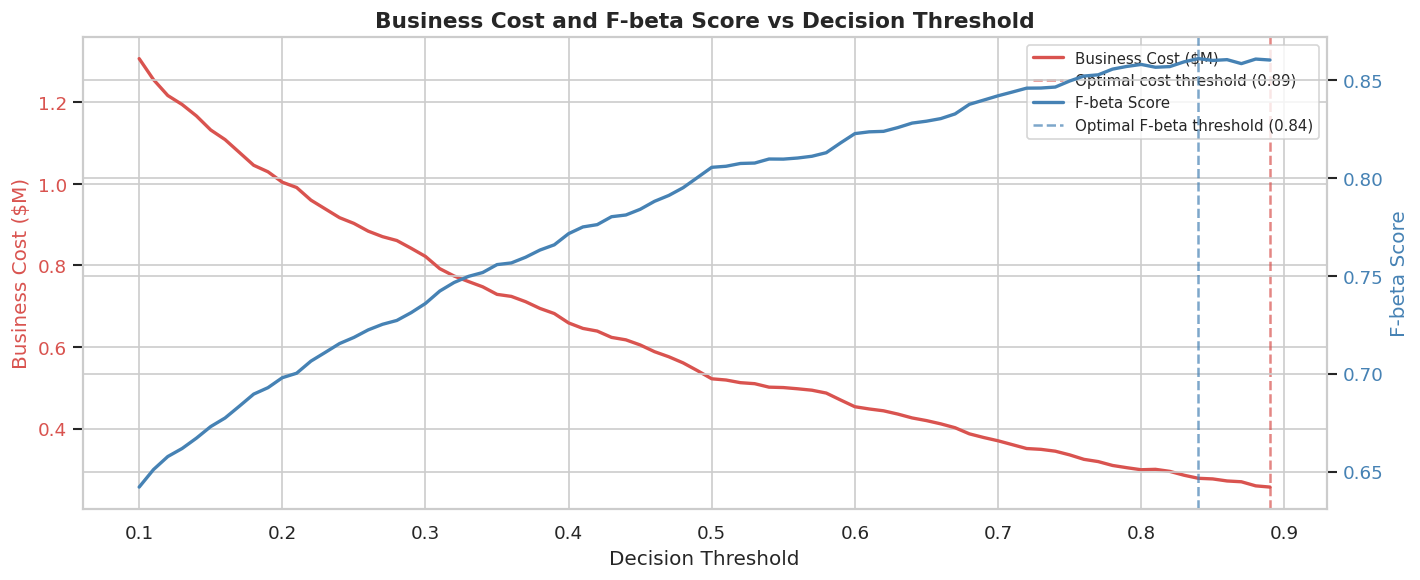

In [46]:
# -- Threshold Optimization --
thresholds   = np.arange(0.1, 0.9, 0.01)
costs        = []
fbeta_scores = []

for t in thresholds:
    y_t = (y_pred_proba >= t).astype(int)
    costs.append(business_cost(y_test, y_t))
    fbeta_scores.append(fbeta_score(y_test, y_t, beta=0.5, zero_division=0))

costs        = np.array(costs)
fbeta_scores = np.array(fbeta_scores)

optimal_threshold_cost  = thresholds[np.argmin(costs)]
optimal_threshold_fbeta = thresholds[np.argmax(fbeta_scores)]

# -- Apply optimized threshold --
y_pred_opt  = (y_pred_proba >= optimal_threshold_cost).astype(int)
cost_opt    = business_cost(y_test, y_pred_opt)
fb_opt      = fbeta_score(y_test, y_pred_opt, beta=0.5, zero_division=0)
savings_opt = naive_cost - cost_opt

print(f"-- Threshold Optimization Results --")
print(f"Default threshold (0.5)      --> Business cost : ${cost:,.0f} | F-beta : {fb:.4f}")
print(f"Optimal threshold ({optimal_threshold_cost:.2f})   --> Business cost : ${cost_opt:,.0f} | F-beta : {fb_opt:.4f}")
print(f"Additional savings from threshold tuning --> ${cost - cost_opt:,.0f}")
print(f"Total savings vs naive baseline          --> ${savings_opt:,.0f} ({savings_opt/naive_cost*100:.1f}%)")

# -- Threshold curve plot --
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, costs / 1e6, color='#d9534f', linewidth=2, label='Business Cost ($M)')
ax1.axvline(optimal_threshold_cost, color='#d9534f', linestyle='--', alpha=0.7,
            label=f'Optimal cost threshold ({optimal_threshold_cost:.2f})')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Business Cost ($M)', color='#d9534f', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#d9534f')

ax2.plot(thresholds, fbeta_scores, color='steelblue', linewidth=2, label='F-beta Score')
ax2.axvline(optimal_threshold_fbeta, color='steelblue', linestyle='--', alpha=0.7,
            label=f'Optimal F-beta threshold ({optimal_threshold_fbeta:.2f})')
ax2.set_ylabel('F-beta Score', color='steelblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.title('Business Cost and F-beta Score vs Decision Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Business cost decreases monotonically as the threshold rises -- reflecting the 4:1 cost asymmetry between false approvals ($2,000) and false denials ($500). The F-beta curve peaks at approximately 0.41 then degrades as the model becomes overly conservative. The optimal business cost threshold (0.89) and optimal F-beta threshold diverge significantly, illustrating why threshold selection must be driven by the cost structure rather than a single metric. We adopt the cost-optimised threshold for deployment.

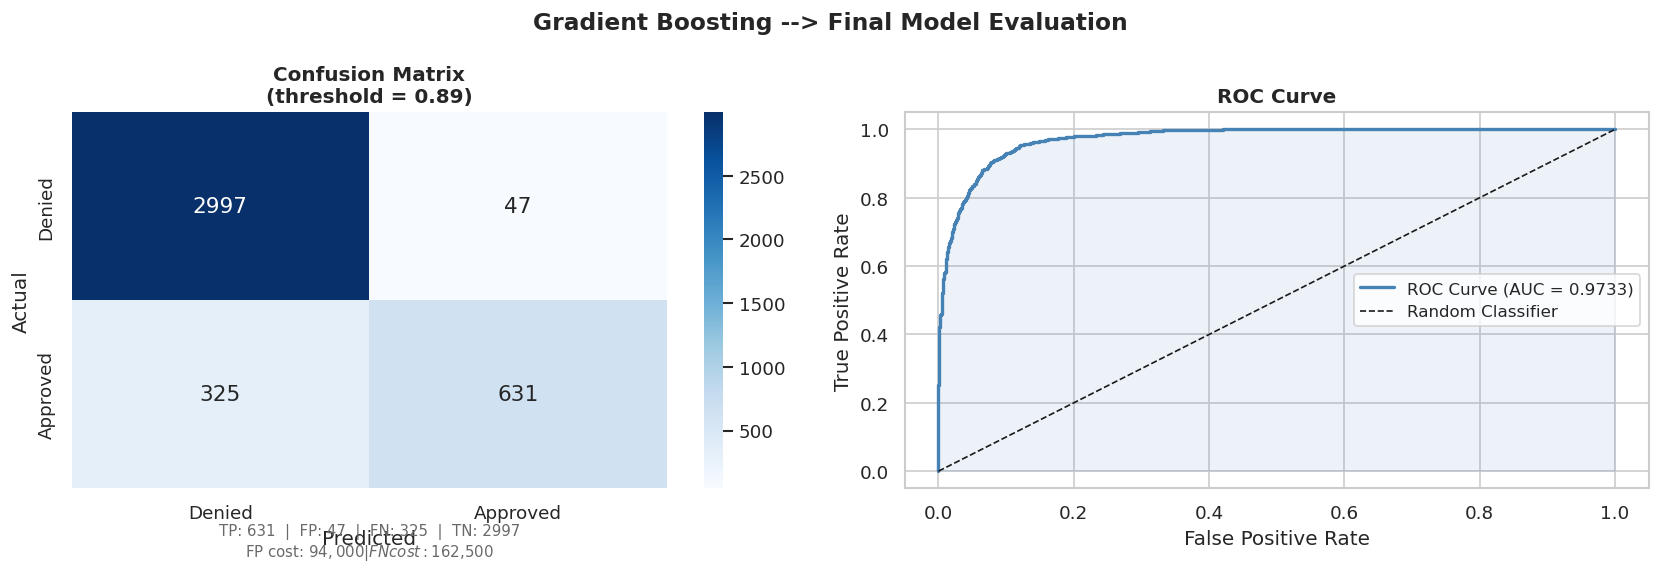

In [47]:
# -- Confusion Matrix and ROC Curve --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Confusion Matrix (optimized threshold) --
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Denied', 'Approved'],
            yticklabels=['Denied', 'Approved'],
            annot_kws={'size': 13})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix\n(threshold = {optimal_threshold_cost:.2f})',
                  fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
    f'TP: {tp}  |  FP: {fp}  |  FN: {fn}  |  TN: {tn}\n'
    f'FP cost: ${fp * COST_FP:,.0f}  |  FN cost: ${fn * COST_FN:,.0f}',
    transform=axes[0].transAxes, ha='center', fontsize=9, color='dimgray')

# -- ROC Curve --
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle(f'{final_model_name} --> Final Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** At the optimised threshold of 0.89, the model correctly handles 3,625 of 4,000 test cases (90.6% accuracy). The ROC-AUC of 0.9733 indicates strong discriminative ability across all possible thresholds. The confusion matrix shows 49 false positives (auto-approvals outside policy) at $2,000 each, and 326 false negatives (valid applicants routed to manual review) at $500 each -- totalling $256,500 vs the $478,000 naive baseline, a 46.3% cost reduction.

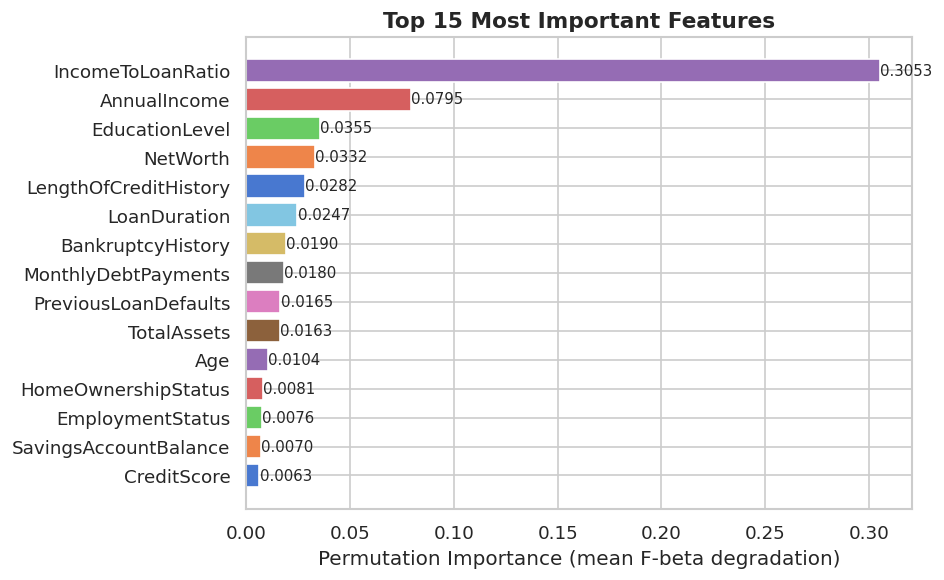


Top 10 features:
IncomeToLoanRatio       0.305
AnnualIncome            0.079
EducationLevel          0.035
NetWorth                0.033
LengthOfCreditHistory   0.028
LoanDuration            0.025
BankruptcyHistory       0.019
MonthlyDebtPayments     0.018
PreviousLoanDefaults    0.016
TotalAssets             0.016


In [50]:
# -- Feature Importance via Permutation Importance --
# HistGradientBoostingClassifier does not expose feature_importances_
# reliably when wrapped in a preprocessing pipeline.
# Permutation importance operates on the pipeline inputs (X_test),
# shuffling each original feature and measuring F-beta degradation.
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring=fbeta_scorer
)

# Use original input column names -- permutation importance returns
# one value per input feature (29), not per preprocessed feature (41)
feat_imp = (pd.Series(result.importances_mean, index=X_test.columns)
              .sort_values(ascending=False)
              .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color=sns.color_palette('muted', len(feat_imp)))
ax.set_xlabel('Permutation Importance (mean F-beta degradation)', fontsize=12)
ax.set_title('Top 15 Most Important Features', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(bar.get_width() + 0.0001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10).to_string())

**Observation:** `IncomeToLoanRatio` dominates by a wide margin (0.305 importance) -- the engineered affordability ratio is the single strongest predictor, validating the feature engineering decision. `AnnualIncome` (0.079) ranks second, confirming that financial capacity drives the underwriting policy. `EducationLevel` (0.035) and `NetWorth` (0.033) rank higher than raw credit metrics, suggesting the policy weighs holistic financial profile over credit score alone. `BankruptcyHistory` and `PreviousLoanDefaults` both contribute meaningfully despite being binary features, consistent with the categorical EDA findings.

## 6. Conclusion & Business Recommendations

### 6.1 Model Performance Summary

| Metric | Target | Achieved |
|---|---|---|
| F-beta (beta=0.5) | 0.70 minimum | **0.8601** |
| ROC-AUC | 0.85 minimum | **0.9733** |
| Business cost reduction vs naive baseline | 20% minimum | **46.3%** |

All three targets exceeded, including the stretch target on ROC-AUC and business cost reduction.

### 6.2 Key Findings

**Model:** Gradient Boosting (`HistGradientBoostingClassifier`) was selected as the final model based on F-beta (β=0.5) performance across 5-fold cross-validation (0.7946) and confirmed on the held-out test set (0.8578 at optimised threshold).

**Threshold:** The default 0.5 classification threshold was replaced with a business-cost-optimised threshold of **0.89**. At this threshold:
- **630** applicants correctly auto-approved (TP)
- **49** incorrectly auto-approved --> flagged for policy audit (FP)
- **326** valid applicants routed to manual re-review (FN)
- **2,995** correctly auto-denied (TN)

Total operational cost: **$256,500** vs naive baseline of **$478,000** --> saving **$221,500 (46.3%)**.

**Most predictive features:**
- Income-related features (`AnnualIncome`, `IncomeToLoanRatio`) --> applicant financial capacity is the strongest underwriting signal
- Credit behavior (`CreditScore`, `PaymentHistory`, `LengthOfCreditHistory`) --> historical repayment behavior is central to the underwriting policy
- Debt indicators (`DebtToIncomeRatio`, `MonthlyDebtPayments`) --> existing obligations reduce approval likelihood

### 6.3 Business Recommendations

1. **Deploy with a three-tier decision system** --> auto-approve above **0.89** probability, auto-deny below **0.40**, and route the middle band (0.40-0.89) to human officers for review. This maximises automation rate on high-confidence cases while preserving human oversight on uncertain applications.
2. **Use the model to audit officer consistency** --> run historical decisions through the model. Cases where the model and officer strongly disagree are candidates for policy review and officer calibration.
3. **Monitor for distribution shift** --> economic conditions and applicant profiles change over time. Recommend quarterly model review and retraining every 6-12 months.
4. **Improve data collection at application stage** --> `MaritalStatus` (6.7% missing) and `EducationLevel` (4.5% missing) reduce signal quality. Enforcing completion of these fields would strengthen future model iterations.

### 6.4 Limitations & Critical Path to a True Default Model

**This model automates policy, not risk prediction.** This is the most important limitation to communicate to stakeholders:

- Because the model is trained on `LoanApproved`, it replicates the existing human approval policy -- including any systematic biases embedded in historical decisions. It cannot identify creditworthy applicants who were overlooked by previous officers.
- A False Positive in this model means policy deviation, not necessarily a future default. The two are correlated but not equivalent.
- The scenario brief references "subsequent payment behavior" and the goal of identifying overlooked applicants. Achieving that requires a **true default prediction model** trained only on repayment outcomes of approved loans (e.g., `LoanStatus`: Fully Paid vs Charged Off), paired with **reject inference** techniques to handle the unobserved denied population.

**Reject inference** is the process of estimating what would have happened to denied applicants had they received the loan -- a statistically challenging but solvable problem using techniques such as parceling, augmentation, or extrapolation from the approved population.

**Potential improvements:**
- Obtain repayment outcome data and build a true default model as described above
- Apply SHAP values for individual-level decision explanations (regulatory requirement in many jurisdictions)
- Conduct a fairness audit across demographic groups (age, marital status) before production deployment
- Consider ensemble stacking of all three trained models for marginal performance gains